In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
# This class generates random sequences and their reversed versions for training/testing
class ReverseDataset:
    def __init__(self, num_categories, seq_len, size):
        # Number of possible values in each sequence position
        self.num_categories = num_categories
        # Length of each sequence
        self.seq_len = seq_len
        # Number of samples in the dataset
        self.size = size

        # Generate random integer sequences of shape (size, seq_len)
        self.data = np.random.randint(self.num_categories, size=(self.size, self.seq_len))
        # The reversed version of each sequence
        self.labels = np.flip(self.data, axis=1)

    def __len__(self):
        # Return the number of samples
        return self.size

    def __getitem__(self, idx):
        # Return a tuple: (sequence, reversed sequence)
        return self.data[idx], self.labels[idx]


This class creates random sequences of numbers and their reversed versions. It is used to generate training and test data for the sequence reversal task. Each item in the dataset is a pair: the original sequence and the sequence with its order reversed.

In [3]:
def make_dataset(dataset, batch_size, shuffle=True, drop_last=True):
    # Extract all samples
    x_all = np.stack([dataset[i][0] for i in range(len(dataset))])
    y_all = np.stack([dataset[i][1] for i in range(len(dataset))])

    tf_ds = tf.data.Dataset.from_tensor_slices((x_all, y_all))
    if shuffle:
        tf_ds = tf_ds.shuffle(buffer_size=len(dataset))
    tf_ds = tf_ds.batch(batch_size, drop_remainder=drop_last)
    return tf_ds

In [4]:
from functools import partial

NUM_CATEGORIES = 10
SEQ_LEN = 16

dataset = partial(ReverseDataset, num_categories=NUM_CATEGORIES, seq_len=SEQ_LEN)

train_dataset = dataset(size=50000)
val_dataset = dataset(size=1000)
test_dataset = dataset(size=10000)

train_loader = make_dataset(train_dataset, batch_size=128, shuffle=True, drop_last=True)
val_loader = make_dataset(val_dataset, batch_size=128)
test_loader = make_dataset(test_dataset, batch_size=128)

In [5]:
# Get first batch
for x_batch, y_batch in train_loader.take(1):
    # Get first sequence in the batch
    inp_data = x_batch[0].numpy()
    labels = y_batch[0].numpy()

print("Input data:", inp_data)
print("Labels:    ", labels)

Input data: [2 1 0 0 2 8 5 7 3 5 5 7 6 5 1 0]
Labels:     [0 1 5 6 7 5 5 3 7 5 8 2 0 0 1 2]


In [6]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model

        # Create a matrix of shape [max_len, d_model]
        pos = np.arange(max_len)[:, np.newaxis]           # shape: [max_len, 1]
        i = np.arange(d_model)[np.newaxis, :]            # shape: [1, d_model]

        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        # Apply sin to even indices, cos to odd indices
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        # Register as a constant tensor
        self.pos_encoding = tf.constant(angle_rads, dtype=tf.float32)  # shape [max_len, d_model]

    def call(self, x):
        seq_len = tf.shape(x)[1]
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pos_encoding[tf.newaxis, :seq_len, :]

In [20]:
# This class builds a transformer-based neural network for sequence tasks
class TransformerPredictor(Model):
    def __init__(self, input_dim, model_dim, num_classes, num_heads, num_layers,
                 dropout=0.0, input_dropout=0.0):
        super().__init__()
        # Dropout applied to input embeddings for regularization
        self.input_dropout = layers.Dropout(input_dropout)
        # Embedding layer: turns integer tokens into dense vectors
        self.token_embedding = layers.Embedding(input_dim=input_dim, output_dim=model_dim)
        # Dense layer for projecting float features (if used)
        self.input_dense = layers.Dense(model_dim)
        # Adds positional information to the input sequence
        self.positional_encoding = PositionalEncoding(model_dim)
        # List of transformer attention layers
        self.transformer_layers = [
            layers.MultiHeadAttention(num_heads=num_heads, key_dim=model_dim)
            for _ in range(num_layers)
        ]
        # List of feed-forward networks for each transformer layer
        self.ffns = [
            tf.keras.Sequential([
                layers.Dense(2 * model_dim, activation='relu'),  # Expands then contracts
                layers.Dense(model_dim)
            ]) for _ in range(num_layers)
        ]
        # Dropout for regularization after attention/ffn
        self.dropout = layers.Dropout(dropout)
        # Layer normalization for each transformer block
        self.layernorms = [layers.LayerNormalization() for _ in range(num_layers)]
        # Final output network: projects to class logits
        self.output_net = tf.keras.Sequential([
            layers.Dense(model_dim, activation='relu'),
            layers.LayerNormalization(),
            layers.Dropout(dropout),
            layers.Dense(num_classes)
        ])

    def call(self, x, mask=None, training=False, add_positional_encoding=True, return_attention=False):
        # Embed input tokens
        x = self.token_embedding(tf.cast(x, tf.int32))
        # Apply input dropout
        x = self.input_dropout(x, training=training)
        # Add positional encoding if requested
        if add_positional_encoding:
            x = self.positional_encoding(x)

        attention_maps = []  # Store attention weights for analysis
        # For each transformer layer
        for attn, ffn, ln in zip(self.transformer_layers, self.ffns, self.layernorms):
            # Compute attention output and weights
            attn_out, attn_weights = attn(
                x, x, attention_mask=mask, return_attention_scores=True
            )
            attention_maps.append(attn_weights)  # Save attention weights
            # Add attention output (with dropout) and normalize
            x = ln(x + self.dropout(attn_out, training=training))
            # Add feed-forward output (with dropout) and normalize
            x = ln(x + self.dropout(ffn(x), training=training))
        # Project to output classes
        x = self.output_net(x, training=training)
        # Optionally return attention maps for inspection
        if return_attention:
            return x, attention_maps
        return x


This class builds a transformer-based neural network model. It takes sequences as input and uses attention mechanisms to learn complex relationships between sequence elements. The model is designed to predict outputs for each position in the input sequence.

In [21]:
def train_reverse(**kwargs):
    model = TransformerPredictor(**kwargs)
    optimizer = tf.keras.optimizers.Adam(learning_rate = kwargs.get("lr", 1e-3))
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    model.fit(train_loader, validation_data=val_loader, epochs=10)
    val_loss, val_acc = model.evaluate(val_loader)
    test_loss, test_acc = model.evaluate(test_loader)

    result = {"test_acc": test_acc, "val_acc": val_acc}

    return model, result

In [22]:
reverse_model, reverse_result = train_reverse(
    input_dim=train_dataset.num_categories,
    model_dim=32,
    num_heads=1,
    num_classes=train_dataset.num_categories,
    num_layers=1,
    dropout=0.0
    )

Epoch 1/10


C:\Users\sbrad\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_predictor_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.4147 - loss: 1.5777 - val_accuracy: 0.9976 - val_loss: 0.0587
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9999 - loss: 0.0133 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 9.7753e-04 - val_accuracy: 1.0000 - val_loss: 7.2408e-04
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 5.5151e-04 - val_accuracy: 1.0000 - val_loss: 4.3789e-04
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 3.4888e-04 - val_accuracy: 1.0000 - val_loss: 2.8831e-04
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 1.0000 - loss: 2.3580e-04 - val_accuracy: 1.0000 - val_loss: 2.0064e-04
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - l

In [23]:
print(f"Val accuracy:  {(100.0 * reverse_result['val_acc']):4.2f}%")
print(f"Test accuracy: {(100.0 * reverse_result['test_acc']):4.2f}%")

Val accuracy:  100.00%
Test accuracy: 100.00%


In [24]:
# Get a batch
for x_batch, y_batch in train_loader.take(1):
    preds, attn_maps = reverse_model(x_batch, return_attention=True, training=False)
    break

# attn_maps is a list of attention matrices, one per layer
print([a.shape for a in attn_maps])

[TensorShape([128, 1, 16, 16])]


In [17]:
import matplotlib.pyplot as plt

In [18]:
def plot_attention_maps(input_data, attn_maps, idx=0):
    input_data = input_data.numpy()[idx]
    attn_maps = [m.numpy()[idx] for m in attn_maps]

    num_heads = attn_maps[0].shape[0]
    num_layers = len(attn_maps)
    seq_len = input_data.shape[0]
    fig_size = 4 if num_heads == 1 else 3
    fig, ax = plt.subplots(num_layers, num_heads, figsize=(num_heads*fig_size, num_layers*fig_size))
    if num_layers == 1:
        ax = [ax]
    if num_heads == 1:
        ax = [[a] for a in ax]
    for row in range(num_layers):
        for column in range(num_heads):
            ax[row][column].imshow(attn_maps[row][column], origin='lower', vmin=0)
            ax[row][column].set_xticks(list(range(seq_len)))
            ax[row][column].set_xticklabels(input_data.tolist())
            ax[row][column].set_yticks(list(range(seq_len)))
            ax[row][column].set_yticklabels(input_data.tolist())
            ax[row][column].set_title(f"Layer {row+1}, Head {column+1}")
    fig.subplots_adjust(hspace=0.5)
    plt.show()

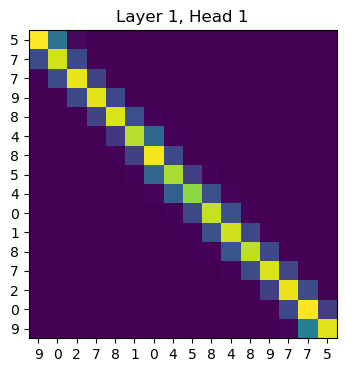

In [19]:
plot_attention_maps(x_batch, attn_maps)